In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, lasso_path, ridge_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 1. Generate synthetic data
np.random.seed(42)
n_samples, n_features = 100, 10
X = np.random.randn(n_samples, n_features)


In [2]:
# True coefficients: only first 3 are nonzero
true_coef = np.zeros(n_features)
true_coef[:3] = [1.5, -2.0, 0.5]

y = X @ true_coef + np.random.randn(n_samples) * 0.5

In [3]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Fit OLS, Ridge, LASSO
ols = LinearRegression().fit(X_train, y_train)
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=0.1, max_iter=10000).fit(X_train, y_train)

print("True coefficients: ", true_coef)
print("OLS coefficients:  ", np.round(ols.coef_, 2))
print("Ridge coefficients:", np.round(ridge.coef_, 2))
print("LASSO coefficients:", np.round(lasso.coef_, 2))

True coefficients:  [ 1.5 -2.   0.5  0.   0.   0.   0.   0.   0.   0. ]
OLS coefficients:   [ 1.49 -2.02  0.54  0.04 -0.06  0.   -0.15  0.06  0.01 -0.01]
Ridge coefficients: [ 1.46 -1.99  0.52  0.04 -0.06  0.01 -0.14  0.06  0.02 -0.  ]
LASSO coefficients: [ 1.36 -1.91  0.39  0.   -0.    0.   -0.    0.    0.    0.  ]


In [4]:
# 3. Bias–variance tradeoff (train/test error vs lambda)
lambdas = np.logspace(-3, 2, 30)
ridge_train, ridge_test, lasso_train, lasso_test = [], [], [], []

for lam in lambdas:
    r = Ridge(alpha=lam).fit(X_train, y_train)
    l = Lasso(alpha=lam, max_iter=10000).fit(X_train, y_train)
    ridge_train.append(mean_squared_error(y_train, r.predict(X_train)))
    ridge_test.append(mean_squared_error(y_test, r.predict(X_test)))
    lasso_train.append(mean_squared_error(y_train, l.predict(X_train)))
    lasso_test.append(mean_squared_error(y_test, l.predict(X_test)))

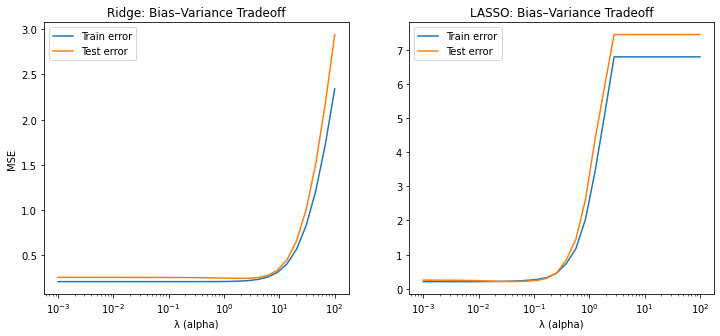

In [5]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(lambdas, ridge_train, label="Train error")
plt.plot(lambdas, ridge_test, label="Test error")
plt.xscale("log")
plt.title("Ridge: Bias–Variance Tradeoff")
plt.xlabel("λ (alpha)")
plt.ylabel("MSE")
plt.legend()

plt.subplot(1,2,2)
plt.plot(lambdas, lasso_train, label="Train error")
plt.plot(lambdas, lasso_test, label="Test error")
plt.xscale("log")
plt.title("LASSO: Bias–Variance Tradeoff")
plt.xlabel("λ (alpha)")
plt.legend()
plt.show()


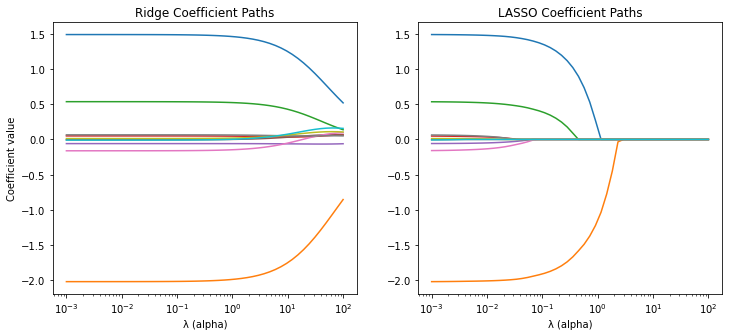

In [6]:
# 4. Coefficient paths
alphas_lasso, coefs_lasso, _ = lasso_path(X_train, y_train, alphas=np.logspace(-3, 2, 50))
alphas_ridge = np.logspace(-3, 2, 50)
coefs_ridge = np.array([ridge_regression(X_train, y_train, alpha=a) for a in alphas_ridge]).T

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for coef in coefs_ridge:
    plt.plot(alphas_ridge, coef)
plt.xscale("log")
plt.title("Ridge Coefficient Paths")
plt.xlabel("λ (alpha)")
plt.ylabel("Coefficient value")

plt.subplot(1,2,2)
for coef in coefs_lasso:
    plt.plot(alphas_lasso, coef)
plt.xscale("log")
plt.title("LASSO Coefficient Paths")
plt.xlabel("λ (alpha)")
plt.show()